Purpose
-------
    Assess biogeochemical fields from ACCESS-OM2-WOMBATmid
    
    We use monthly climatologies for assessment (not specific years)
    
    The fields we are assessing are:
        1  - Surface NO3 at the equatorial band    --> World Ocean Atlas 2023 
        2  - Surface Silicic acid globally         --> World Ocean Atlas 2023 
        3  - Surface DOC concentration globally    --> Panaoitis et al. (2025)
        4  - Surface dFe globally                  --> Huang et al. 2022 Frontiers in Marine Science
        5  - Surface Chlorophyll                   --> Sauzede et al. (2016 JGR: Oceans)
        6  - Depth of max Chlorophyll              --> Sauzede et al. (2016 JGR: Oceans)
        7  - Net Primary Production                --> Carbon-based productivity model (CbPM) 
        8  - Primary nutrient limitation (N or Fe) --> Browning & Moore 2023 Nature Communications
        9  - Air-sea CO2 flux (Southern Ocean)     --> Chau et al. (2022)
        10 - Sinking POC fluxes                    --> Mouw et al. (2016)
        11 - Sinking PIC fluxes                    --> Mouw et al. (2016)
        12 - Sinking BSi fluxes                    --> Mouw et al. (2016)
        13 - Fe:C ratios of phytoplankton          --> Twining et al. (2021)
        14 - Si:C ratios of diatoms                --> Twining et al. (2021)
        15 - fraction of microphytoplankton        --> Sathyendranath et al. (2020)
        16 - NH4:DIN - pNH4:pNPP ratio             --> Buchanan et al. (2025)
        
        

## imports

In [1]:
import sys
import os

import numpy as np
import pandas as pd
import xarray as xr
import scipy as sci
import h5py as h5

import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean.cm as cmo
from cmocean.tools import lighten

# regridding package
import xesmf as xe

# statistics package
import skill_metrics as sm

# fit b-values
from scipy.optimize import curve_fit


# print versions of packages
print("python version =",sys.version[:5])
print("numpy version =", np.__version__)
print("pandas version =", pd.__version__)
print("xarray version =", xr.__version__)
print("scipy version =", sci.__version__)
print("h5py version =", h5.__version__)
print("matplotlib version =", sys.modules[plt.__package__].__version__)
print("cmocean version =", sys.modules[cmo.__package__].__version__)
print("cartopy version =", sys.modules[ccrs.__package__].__version__)
print("xesmf version =", xe.__version__)


moddir = "/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/"
obsdir = "/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/data/observations"
os.chdir(obsdir)


python version = 3.10.
numpy version = 2.2.5
pandas version = 2.3.3
xarray version = 2025.4.0
scipy version = 1.15.3
h5py version = 3.15.1
matplotlib version = 3.10.6
cmocean version = v3.0.3
cartopy version = 0.24.1
xesmf version = 0.8.10


In [3]:
import warnings
warnings.filterwarnings('ignore')

# start up a dask client

In [4]:
import dask
from dask.distributed import Client, LocalCluster
cluster = LocalCluster(n_workers=28, threads_per_worker=2, memory_limit="16GB")
client  = Client(cluster)
client  # shows dashboard link



Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 56,Total memory: 417.23 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37727,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:46737,Total threads: 2
Dashboard: /proxy/43411/status,Memory: 14.90 GiB
Nanny: tcp://127.0.0.1:40913,


2026-08-26 12:57:25,697 - tornado.application - ERROR - Uncaught exception GET /individual-task-stream/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='gadi-cpu-bdw-0075.gadi.nci.org.au:36092', method='GET', uri='/individual-task-stream/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/g/data/es60/pjb581/miniforge3/envs/model_assessment_env/lib/python3.10/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
  File "/g/data/es60/pjb581/miniforge3/envs/model_assessment_env/lib/python3.10/site-packages/tornado/web.py", line 3375, in wrapper
    return method(self, *args, **kwargs)
  File "/g/data/es60/pjb581/miniforge3/envs/model_assessment_env/lib/python3.10/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.prot

## load data

In [6]:
%%time

os.chdir(obsdir)

bottle_data = xr.open_dataset("sots_monthly_climatology.nc").squeeze()
pco2_data = xr.open_dataset("sots_sofs_pco2_monthly_climatology.nc").squeeze()
chl_data = xr.open_dataset("sots_chl_30m_monthly_climatology.nc").squeeze()
zoo_data = xr.open_dataset("maredat_zoo.nc").squeeze()
bac_data = pd.read_csv("TAN1810_Bacteria_Salp_biomass_converted_mmolC_m3.csv")

### cut out depths > 500 metres
bottle_data = bottle_data.sel(depth=slice(0,500))
zoo_data = zoo_data.sel(DEPTH=slice(0,500))

### Bacterial data
bac_data = bac_data[['Depth water [m]','Bact C [mmol C/m**3] (20 fg C/cell)']]
bac_data = bac_data.sort_values(by='Depth water [m]', ascending=True)
bac_data = bac_data.rename(columns={'Depth water [m]':'depth', 'Bact C [mmol C/m**3] (20 fg C/cell)':'bac'})
bac_data_mean = bac_data.groupby('depth', as_index=False).mean()
bac_data_std = bac_data.groupby('depth', as_index=False).std()
bac_data_mean
bac_data_smooth = pd.DataFrame({
    'depth':bac_data_mean['depth'].values, 
    'mean':bac_data_mean['bac'].values, 
    'std':bac_data_std['bac'].values
})
bac_data_smooth

### Argo data
argo_data = xr.open_dataset("ARGO_SOTS.nc").squeeze()
argo_data

''' NOTE:

POC data is very likely to be the living + dead particulates

However, we tried including the dead + living, and the optimisation procedure was poorly constrained

'''


CPU times: user 655 ms, sys: 356 ms, total: 1.01 s
Wall time: 1.44 s


' NOTE:\n\nPOC data is very likely to be the living + dead particulates\n\nHowever, we tried including the dead + living, and the optimisation procedure was poorly constrained\n\n'

### Annika broken stick b-value functions

In [7]:
%%time

# define spl model (simple power law)
def spl(x, b, cs):
    return (x / x[0]) ** (-b) * cs

# define bpl model (broken power law)
def bpl(x, b1, b2, cd, z_trans):
    return np.where(x < z_trans, (x/z_trans)**(-b1) * cd, (x/z_trans)**(-b2) * cd)

def r2_score_numpy(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    return 1 - ss_res / ss_tot


CPU times: user 5 μs, sys: 12 μs, total: 17 μs
Wall time: 29.8 μs


## Now, load the model output

In [9]:
%%time

vars2d = ['pco2', 'dic_stf', 'mlotst']
vars3d = ['thetao', 'so', 
          'phy', 'dia', 'pchl', 'dchl', 
          'o2', 'no3', 'nh4', 'fe', 'sil',
          'sdet', 'ldet', 'sdet_vmove', 'ldet_vmove',
          'zoo', 'mes', 'lbac', 'obac', 'sbac']

mod = {}
for i in range(1, 2049):
    if i % 50 == 0: print(i)
    for vv in vars2d:
        mod[vv + "_%i"%(i)] = xr.open_dataset(f'/scratch/es60/pjb581/access-om3/archive/om3_mom6_1D-SOTSfull_opt%i/output009/access-om3.mom6.2d.%s.1day.mean.1909.nc'%(i,vv))[vv].isel(yh=1,xh=1)
    for vv in vars3d:
        mod[vv + "_%i"%(i)] = xr.open_dataset(f'/scratch/es60/pjb581/access-om3/archive/om3_mom6_1D-SOTSfull_opt%i/output009/access-om3.mom6.3d.%s.1day.mean.1909.nc'%(i,vv))[vv].isel(yh=1,xh=1)



50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150
1200
1250
1300
1350
1400
1450
1500
1550
1600
1650
1700
1750
1800
1850
1900
1950
2000
CPU times: user 29min 35s, sys: 11min 26s, total: 41min 1s
Wall time: 49min 13s


### Calculate the b values in the upper and lower water column

In [10]:
%%time

def fit_one_experiment_light(exp, sdet, ldet, mlotst, phy, dia, depth_full):

    depth_da = xr.DataArray(
        depth_full,
        dims=["zl"],
        coords={"zl": depth_full}
    )

    poc = (sdet + ldet) * 1.035 * 1e6
    zprod = mlotst
    living = (phy + dia) * 1.035 * 1e6
    D2L = poc / living

    poc_interp = poc.interp(zl=depth_full).transpose("time", "zl")

    mask = (
        (depth_da > zprod) &
        (depth_da < 1000.0)
    ).transpose("time", "zl")

    poc_masked = poc_interp.where(mask)
    depth_2d = depth_da.broadcast_like(poc_masked)
    depth_masked = depth_2d.where(mask)

    time_coord = poc_masked["time"]
    ntime = poc_masked.sizes["time"]

    b_spl      = np.full(ntime, np.nan)
    r2_spl     = np.full(ntime, np.nan)
    b1_bpl     = np.full(ntime, np.nan)
    b2_bpl     = np.full(ntime, np.nan)
    cd_bpl     = np.full(ntime, np.nan)
    ztrans_bpl = np.full(ntime, np.nan)
    r2_bpl     = np.full(ntime, np.nan)

    poc_arr = poc_masked.values
    dep_arr = depth_masked.values
    zprod_arr = zprod.values

    for tt in range(ntime):

        poc_t = poc_arr[tt, :]
        dep_t = dep_arr[tt, :]
        zprod_t = float(zprod_arr[tt])

        valid = np.isfinite(poc_t) & np.isfinite(dep_t) & (poc_t > 0)

        if valid.sum() < 10:
            continue

        poc_fit = poc_t[valid]
        dep_fit = dep_t[valid]

        try:
            popt_spl, _ = curve_fit(
                spl,
                dep_fit,
                poc_fit,
                sigma=0.6 * poc_fit,
                p0=[0.3, 50],
                bounds=([-10, 0], [10, 150]),
                ftol=1e-3,
                maxfev=5000
            )

            y_pred_spl = spl(dep_fit, *popt_spl)

            b_spl[tt] = popt_spl[0]
            r2_spl[tt] = r2_score_numpy(poc_fit, y_pred_spl)

        except Exception as e:
            print(f"EXP {exp}, time {tt}, SPL failed: {repr(e)}")
            pass

        try:
            popt_bpl, _ = curve_fit(
                bpl,
                dep_fit,
                poc_fit,
                sigma=0.6 * poc_fit,
                p0=[0.5, 0.3, 10, zprod_t + 100],
                bounds=(
                    [-10, -10, 0, zprod_t],
                    [10, 10, 150, zprod_t + 300]
                ),
                ftol=1e-3,
                maxfev=5000
            )

            y_pred_bpl = bpl(dep_fit, *popt_bpl)

            b1_bpl[tt]     = popt_bpl[0]
            b2_bpl[tt]     = popt_bpl[1]
            cd_bpl[tt]     = popt_bpl[2]
            ztrans_bpl[tt] = popt_bpl[3]
            r2_bpl[tt]     = r2_score_numpy(poc_fit, y_pred_bpl)

        except Exception as e:
            print(f"EXP {exp}, time {tt}, BPL failed: {repr(e)}")
            pass

    result = xr.Dataset(
        {
            "b_spl":      ("time", b_spl),
            "r2_spl":     ("time", r2_spl),
            "b1_bpl":     ("time", b1_bpl),
            "b2_bpl":     ("time", b2_bpl),
            "cd_bpl":     ("time", cd_bpl),
            "ztrans_bpl": ("time", ztrans_bpl),
            "r2_bpl":     ("time", r2_bpl),
            "D2L":        D2L,
        },
        coords={"time": time_coord}
    )

    return exp, result

CPU times: user 12 μs, sys: 0 ns, total: 12 μs
Wall time: 23.8 μs


In [11]:
%%time

from dask import delayed, compute

depth_full = np.arange(0, 1100, 1)
exps = np.arange(1, 2049, 1)

tasks = [
    delayed(fit_one_experiment_light)(
        exp,
        mod["sdet_%i" % exp],
        mod["ldet_%i" % exp],
        mod["mlotst_%i" % exp],
        mod["phy_%i" % exp],
        mod["dia_%i" % exp],
        depth_full
    )
    for exp in exps
]

results = compute(*tasks)

fit_ds = xr.concat(
    [result.expand_dims(exp=[exp]) for exp, result in results],
    dim="exp"
)

fit_ds.to_netcdf(moddir + "data/output/poc_attenuation_fits_2048exp_optimisation.nc")

CPU times: user 5min 52s, sys: 2min 33s, total: 8min 26s
Wall time: 21min 26s


#### Load the fits if already pre-computed

In [10]:
fit_ds = xr.open_dataset(moddir + "data/poc_attenuation_fits_2048exp_optimisation.nc")

In [12]:
fit_ds_monthly = fit_ds.groupby("time.month").mean("time", skipna=True)
fit_ds_monthly

<xarray.Dataset> Size: 9MB
Dimensions:     (month: 12, exp: 2048, zl: 75)
Coordinates:
  * exp         (exp) int64 16kB 1 2 3 4 5 6 7 ... 2043 2044 2045 2046 2047 2048
    xh          float64 8B 142.2
    yh          float64 8B -47.25
  * zl          (zl) float64 600B 0.5413 1.681 2.94 ... 5.511e+03 5.805e+03
  * month       (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    b_spl       (month, exp) float64 197kB 0.775 1.082 0.6946 ... 0.7944 0.6841
    r2_spl      (month, exp) float64 197kB 0.923 0.5909 0.818 ... 0.9456 0.837
    b1_bpl      (month, exp) float64 197kB 1.14 2.177 0.5274 ... 0.2385 -0.09315
    b2_bpl      (month, exp) float64 197kB 0.7262 0.9998 ... 0.8038 0.8612
    cd_bpl      (month, exp) float64 197kB 0.1896 0.03961 ... 0.2107 0.06239
    ztrans_bpl  (month, exp) float64 197kB 133.1 124.0 91.61 ... 84.38 126.0
    r2_bpl      (month, exp) float64 197kB 0.9863 0.9467 ... 0.9863 0.9824
    D2L         (month, exp, zl) float32 7MB 0.2196 0.2253 0.2293 ... 2.04 2.04

In [13]:
%%time

# Monthly coordinate
months = np.arange(1, 13)

# Seasonal b1 cycle
# High in peak summer, low in peak winter.
# For Southern Hemisphere:
# peak summer = January/February-ish
# peak winter = July/August-ish
b1_max = 1.5
b1_min = 0.7

b1_mean = (b1_max + b1_min) / 2
b1_amp  = (b1_max - b1_min) / 2

# Peak at month 1, minimum at month 7
b1 = b1_mean + b1_amp * np.cos(2 * np.pi * (months - 1) / 12)

# Constant b2
b2 = np.full_like(b1, 0.2, dtype=float)

# Difference
b1_minus_b2 = b1 - b2

# Build dataset
ideal_monthly = xr.Dataset(
    {
        "b1_bpl": ("month", b1),
        "b2_bpl": ("month", b2),
        "b1_minus_b2": ("month", b1_minus_b2),
    },
    coords={
        "month": months
    }
)

ideal_monthly

CPU times: user 5.56 ms, sys: 710 μs, total: 6.27 ms
Wall time: 6.15 ms


<xarray.Dataset> Size: 384B
Dimensions:      (month: 12)
Coordinates:
  * month        (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    b1_bpl       (month) float64 96B 1.5 1.446 1.3 1.1 0.9 ... 0.9 1.1 1.3 1.446
    b2_bpl       (month) float64 96B 0.2 0.2 0.2 0.2 0.2 ... 0.2 0.2 0.2 0.2 0.2
    b1_minus_b2  (month) float64 96B 1.3 1.246 1.1 0.9 0.7 ... 0.7 0.9 1.1 1.246

### convert bacterial data to observations grid

In [14]:
%%time

target_depth = bottle_data.depth
target_month = bottle_data.month

bac_xr = (
    bac_data_smooth
    .set_index("depth")
    .to_xarray()
)

bac_data_obsgrid = bac_xr.interp(depth=target_depth)
bac_data_obsgrid


CPU times: user 87.9 ms, sys: 45.3 ms, total: 133 ms
Wall time: 941 ms


<xarray.Dataset> Size: 624B
Dimensions:  (depth: 26)
Coordinates:
  * depth    (depth) float64 208B 0.0 20.0 40.0 60.0 ... 440.0 460.0 480.0 500.0
Data variables:
    mean     (depth) float64 208B nan 2.496 2.26 1.984 1.192 ... nan nan nan nan
    std      (depth) float64 208B nan 1.018 0.9538 0.396 ... nan nan nan nan

(200.0, 0.0)

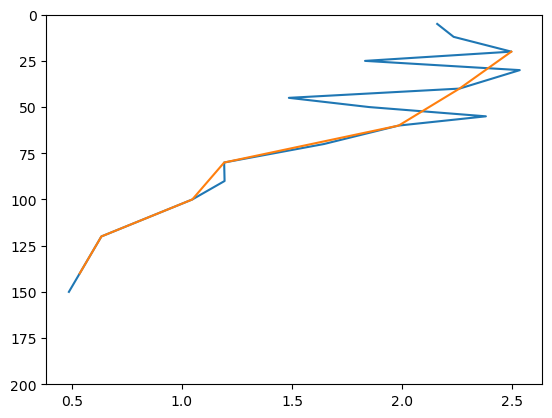

In [15]:
plt.figure()
plt.plot(bac_data_smooth['mean'], bac_data_smooth['depth'])
plt.plot(bac_data_obsgrid['mean'], bac_data_obsgrid['depth'])
plt.ylim(200,0)



### convert ARGO data to observations grid

CPU times: user 138 ms, sys: 36 ms, total: 174 ms
Wall time: 160 ms


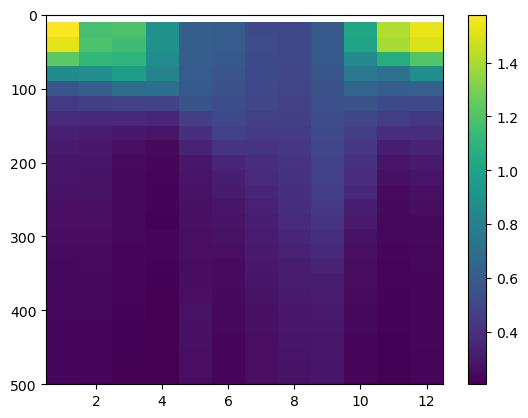

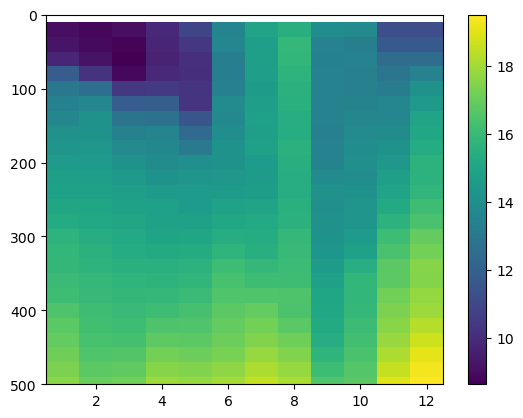

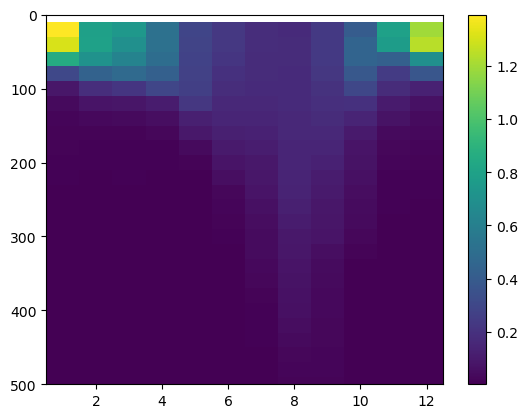

In [16]:
%%time

argo_data_obsgrid = argo_data.interp(pressure=target_depth)
argo_data_obsgrid = argo_data_obsgrid.where(argo_data_obsgrid.depth > 10.0, other=np.nan)

plt.figure()
plt.pcolormesh(argo_data_obsgrid.month, argo_data_obsgrid.depth, argo_data_obsgrid['POC']*0.5/12.0/3)
plt.ylim(500,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(argo_data_obsgrid.month, argo_data_obsgrid.depth, argo_data_obsgrid['NO3'])
plt.ylim(500,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(argo_data_obsgrid.month, argo_data_obsgrid.depth, argo_data_obsgrid['CHL'])
plt.ylim(500,0)
plt.colorbar()


### Convert model data to observations grid

In [17]:
%%time

for i in range(1, 2049):
    if i % 50 == 0: print(i)
    for vv in np.concatenate((vars2d, vars3d)):
        mod[vv + "_%i_obsgrid"%(i)] = mod[vv + "_%i"%(i)].groupby("time.month").mean("time")
        if vv in vars3d:
            mod[vv + "_%i_obsgrid"%(i)] = mod[vv + "_%i_obsgrid"%(i)].interp(zl=target_depth)
            
mod['phy_1_obsgrid']

50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150
1200
1250
1300
1350
1400
1450
1500
1550
1600
1650
1700
1750
1800
1850
1900
1950
2000
CPU times: user 22min 38s, sys: 6min 10s, total: 28min 49s
Wall time: 27min 34s


<xarray.DataArray 'phy' (month: 12, depth: 26)> Size: 2kB
array([[           nan, 1.91714595e-06, 1.65825472e-06, 9.36460318e-07,
        3.05239237e-07, 1.79330815e-07, 1.48074335e-07, 1.38518588e-07,
        1.34196589e-07, 1.31860037e-07, 1.30315132e-07, 1.28237411e-07,
        1.22672178e-07, 1.11221998e-07, 9.17838069e-08, 5.91381958e-08,
        3.28345707e-08, 1.93957543e-08, 1.25786002e-08, 8.61054242e-09,
        6.63473810e-09, 5.00920851e-09, 4.10213960e-09, 3.35752666e-09,
        2.82293261e-09, 2.44191084e-09],
       [           nan, 1.79890321e-06, 1.69804380e-06, 1.53524244e-06,
        4.84494917e-07, 1.62240858e-07, 1.24838556e-07, 1.13439859e-07,
        1.08426763e-07, 1.05758562e-07, 1.04058896e-07, 1.02116717e-07,
        9.79037852e-08, 8.96477935e-08, 7.56636626e-08, 5.13401159e-08,
        3.08710646e-08, 1.86426161e-08, 1.22229492e-08, 8.30262117e-09,
        6.37827718e-09, 4.80486383e-09, 3.92982308e-09, 3.21269605e-09,
        2.69842781e-09, 2.33249616e-09],
       [           nan, 1.67895830e-06, 1.54979020e-06, 1.40963983e-06,
        6.93071257e-07, 1.61995579e-07, 1.07764829e-07, 9.55174198e-08,
        9.04932404e-08, 8.78589558e-08, 8.61936685e-08, 8.44216971e-08,
        8.10341336e-08, 7.46678173e-08, 6.39769155e-08, 4.52188241e-08,
        2.88352418e-08, 1.78377944e-08, 1.18468820e-08, 8.01012801e-09,
        6.13836691e-09, 4.61208765e-09, 3.76689796e-09, 3.07571401e-09,
...
        8.44118081e-07, 7.87771859e-07, 7.55723948e-07, 7.28204499e-07,
        7.00551540e-07, 6.41211974e-07, 5.91872870e-07, 5.59063247e-07,
        4.60905057e-07, 2.98280971e-07, 1.21536760e-07, 5.60607259e-08,
        2.02360429e-08, 1.30053333e-08, 8.89268714e-09, 6.12164720e-09,
        4.67524045e-09, 3.46172854e-09, 2.79834013e-09, 2.25934383e-09,
        1.87805793e-09, 1.61209471e-09],
       [           nan, 1.86133143e-06, 1.51202172e-06, 9.02932665e-07,
        4.45707905e-07, 3.06259687e-07, 2.90702921e-07, 2.83940981e-07,
        2.80219832e-07, 2.77788254e-07, 2.75648782e-07, 2.71298175e-07,
        2.44504948e-07, 1.87224619e-07, 9.97529226e-08, 5.16129216e-08,
        2.12426998e-08, 1.29965849e-08, 8.61736503e-09, 5.90195029e-09,
        4.49871676e-09, 3.32618879e-09, 2.68519949e-09, 2.16439997e-09,
        1.79660459e-09, 1.54069054e-09],
       [           nan, 1.94709410e-06, 1.56750182e-06, 1.00992922e-06,
        3.55458428e-07, 2.16914248e-07, 1.91720330e-07, 1.83776807e-07,
        1.79940612e-07, 1.77779161e-07, 1.76180228e-07, 1.73083965e-07,
        1.60233471e-07, 1.31563930e-07, 8.25408054e-08, 4.63954739e-08,
        2.15222405e-08, 1.28848456e-08, 8.39989360e-09, 5.70160924e-09,
        4.33269419e-09, 3.19750667e-09, 2.57753651e-09, 2.07406562e-09,
        1.71911524e-09, 1.47276764e-09]])
Coordinates:
    xh       float64 8B 142.2
    yh       float64 8B -47.25
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
    zl       (depth) float64 208B 0.0 20.0 40.0 60.0 ... 440.0 460.0 480.0 500.0
  * depth    (depth) float64 208B 0.0 20.0 40.0 60.0 ... 440.0 460.0 480.0 500.0
Attributes:
    units:          mol/kg
    long_name:      Phytoplankton
    cell_methods:   time: mean
    time_avg_info:  average_T1,average_T2,average_DT

## Assess the model fit to the observations

In [18]:
print("put all the observations into a dictionary for iteration")
obsdata = {
    'pco2': pco2_data['pco2_sw'],
    'fgco2': pco2_data['co2_flux_mol_m2_y1'] * (-1),
    'nh4': bottle_data['ammonia'], 
    #'no3': bottle_data['nitrate'], 
    'no3': argo_data_obsgrid['NO3'], 
    'sil': bottle_data['silicate'], 
    'dfe': bottle_data['dFe'], 
    #'poc': bottle_data['POC'], 
    'poc': argo_data_obsgrid['POC']*0.5/12/3.0, 
    'bac': bac_data_obsgrid['mean'], 
    'micro': zoo_data['micro_mean'].sel(DEPTH=slice(0,500)).mean(dim='DEPTH',skipna=True)/12.0,
    'meso': zoo_data['meso_mean'].sel(DEPTH=slice(0,500)).mean(dim='DEPTH',skipna=True)/12.0,
    #'chl_bottle': bottle_data['chlorophyll_total_mv'],
    'chl_bottle': argo_data_obsgrid['CHL'],
    'chl_mooring': chl_data['chlorophyll'],
    'b1mb2': ideal_monthly['b1_minus_b2'],
    'D2L300mD2L50': ideal_monthly['b1_minus_b2']*0.5+2.0
    }


put all the observations into a dictionary for iteration


In [20]:
target_vars = np.array(list(obsdata.keys()))

for i in range(1, 2049):
    if i % 50 == 0: print(i)
    mod[target_vars[0]+"_%i"%(i)] = mod['pco2_%i_obsgrid'%(i)]
    mod[target_vars[1]+"_%i"%(i)] = mod['dic_stf_%i_obsgrid'%(i)]*365*86400
    mod[target_vars[2]+"_%i"%(i)] = mod['nh4_%i_obsgrid'%(i)]*1e6*1.035
    mod[target_vars[3]+"_%i"%(i)] = mod['no3_%i_obsgrid'%(i)]*1e6*1.035
    mod[target_vars[4]+"_%i"%(i)] = mod['sil_%i_obsgrid'%(i)]*1e6*1.035
    mod[target_vars[5]+"_%i"%(i)] = mod['fe_%i_obsgrid'%(i)]*1e9*1.035
    #mod[target_vars[6]+"_%i"%(i)] = (mod['phy_%i_obsgrid'%(i)] + mod['dia_%i_obsgrid'%(i)] + mod['det_%i_obsgrid'%(i)] + mod['bdet_%i_obsgrid'%(i)])*1e6*1.035
    mod[target_vars[6]+"_%i"%(i)] = (mod['sdet_%i_obsgrid'%(i)] + mod['ldet_%i_obsgrid'%(i)])*1e6*1.035
    mod[target_vars[7]+"_%i"%(i)] = (mod['lbac_%i_obsgrid'%(i)] + mod['obac_%i_obsgrid'%(i)] + mod['sbac_%i_obsgrid'%(i)]).sel(month=11,method='nearest')*1e6*1.035
    mod[target_vars[8]+"_%i"%(i)] = (mod['zoo_%i_obsgrid'%(i)].sel(depth=slice(0,200)).mean(dim='depth'))*1e6*1.035
    mod[target_vars[9]+"_%i"%(i)] = (mod['mes_%i_obsgrid'%(i)].sel(depth=slice(0,200)).mean(dim='depth'))*1e6*1.035
    mod[target_vars[10]+"_%i"%(i)] = (mod['pchl_%i_obsgrid'%(i)] + mod['dchl_%i_obsgrid'%(i)])*1e6*1.035*12
    mod[target_vars[11]+"_%i"%(i)] = (mod['pchl_%i_obsgrid'%(i)] + mod['dchl_%i_obsgrid'%(i)]).sel(depth=30.0,method='nearest')*1e6*1.035*12
    mod[target_vars[12]+"_%i"%(i)] = (fit_ds_monthly['b1_bpl'] - fit_ds_monthly['b2_bpl']).sel(exp=i)
    mod[target_vars[13]+"_%i"%(i)] = (fit_ds_monthly['D2L'].sel(zl=300, method='nearest') -
                                      fit_ds_monthly['D2L'].sel(zl=50, method='nearest')).sel(exp=i)




50
100
150
200
250
300
350
400
450
500
550
600
650
700
750
800
850
900
950
1000
1050
1100
1150
1200
1250
1300
1350
1400
1450
1500
1550
1600
1650
1700
1750
1800
1850
1900
1950
2000


In [21]:
target_vars

array(['pco2', 'fgco2', 'nh4', 'no3', 'sil', 'dfe', 'poc', 'bac', 'micro',
       'meso', 'chl_bottle', 'chl_mooring', 'b1mb2', 'D2L300mD2L50'],
      dtype='<U12')

(500.0, 0.0)

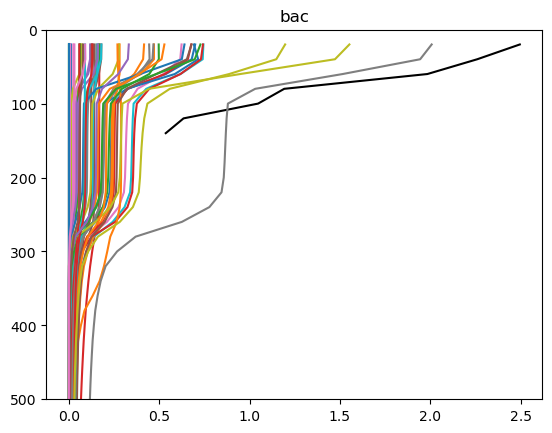

In [22]:
vv = target_vars[7]
plt.figure()
plt.title(vv)
plt.plot(obsdata[vv], target_depth, 'k')
for i in np.arange(1,50,1):
    plt.plot(mod[vv+"_%i"%(i)], target_depth)
plt.ylim(500,0)


chl_bottle


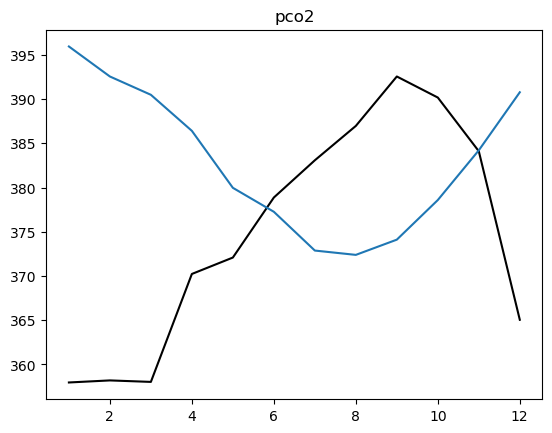

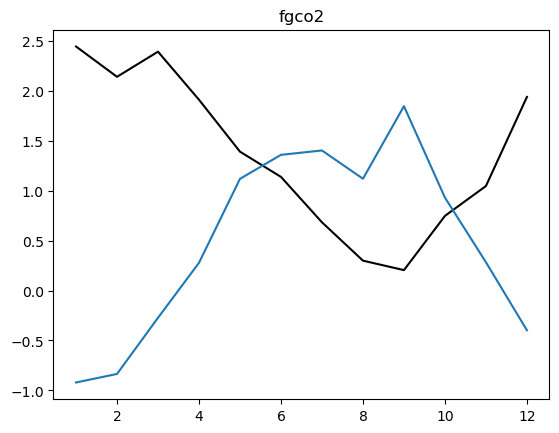

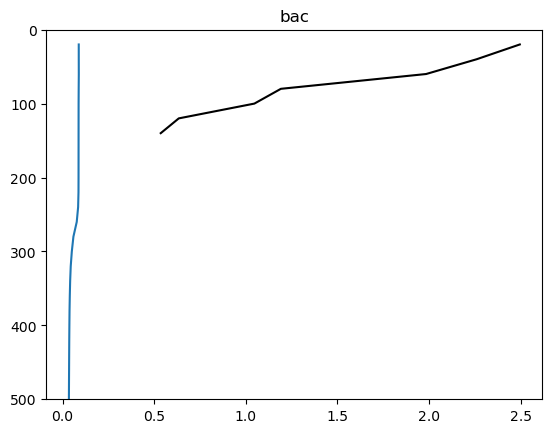

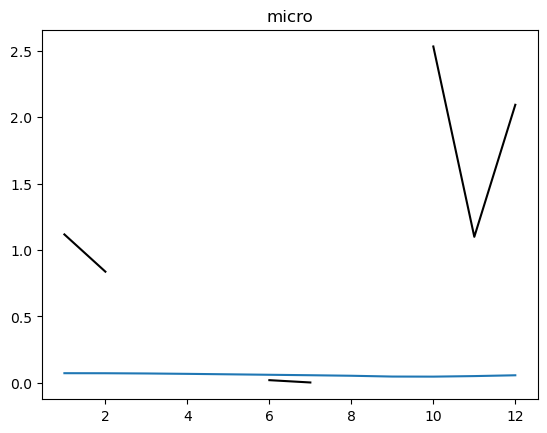

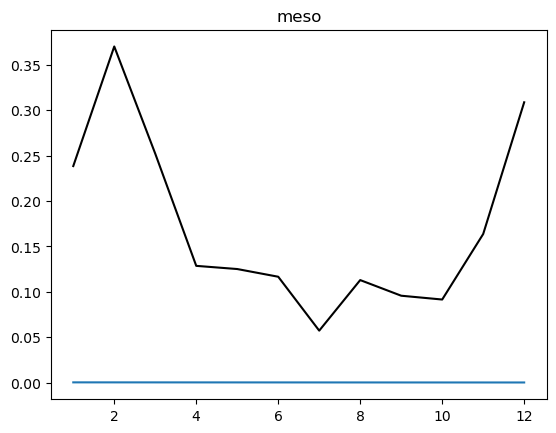

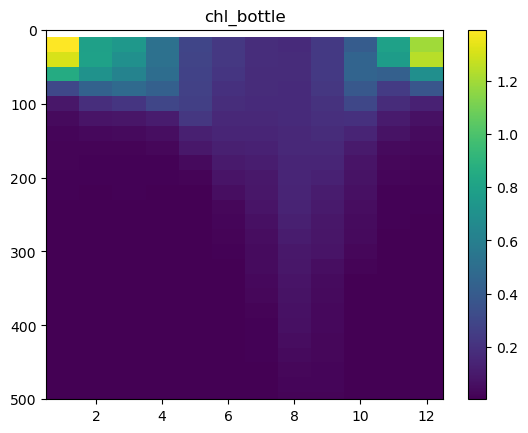

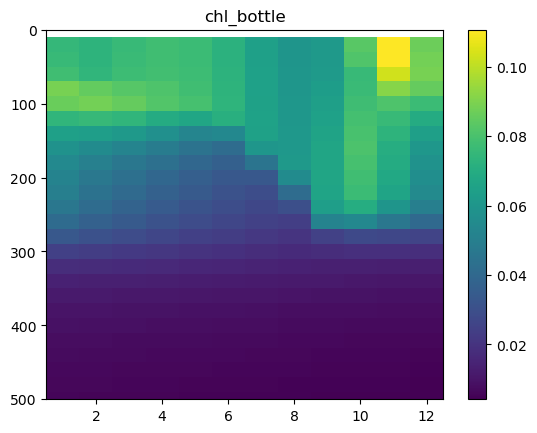

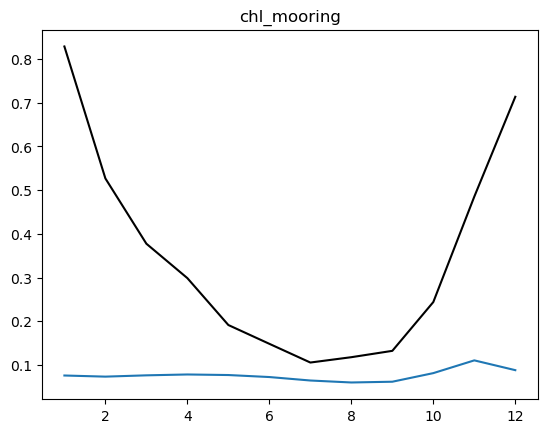

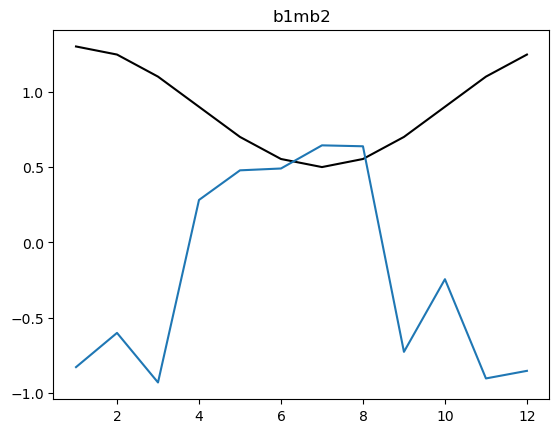

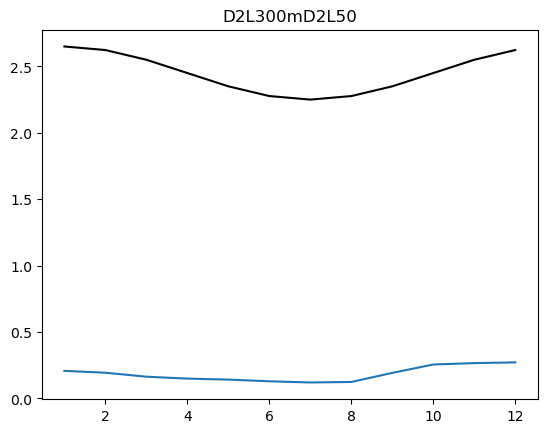

In [23]:
i = 40

vv = target_vars[0]
plt.figure()
plt.title(vv)
plt.plot(target_month, obsdata[vv], 'k')
plt.plot(target_month, mod[vv+"_%i"%(i)])

vv = target_vars[1]
plt.figure()
plt.title(vv)
plt.plot(target_month, obsdata[vv], 'k')
plt.plot(target_month, mod[vv+"_%i"%(i)])

vv = target_vars[7]
plt.figure()
plt.title(vv)
plt.plot(obsdata[vv], target_depth, 'k')
plt.plot(mod[vv+"_%i"%(i)], target_depth)
plt.ylim(500,0)

vv = target_vars[8]
plt.figure()
plt.title(vv)
plt.plot(target_month, obsdata[vv], 'k')
plt.plot(target_month, mod[vv+"_%i"%(i)])

vv = target_vars[9]
plt.figure()
plt.title(vv)
plt.plot(target_month, obsdata[vv], 'k')
plt.plot(target_month, mod[vv+"_%i"%(i)])

vv = target_vars[10]
print(vv)
plt.figure()
plt.title(vv)
plt.pcolormesh(target_month, target_depth, obsdata[vv])
plt.colorbar()
plt.ylim(500,0)
plt.figure()
plt.title(vv)
plt.pcolormesh(target_month, target_depth, mod[vv+"_%i"%(i)].T)
plt.colorbar()
plt.ylim(500,0)

vv = target_vars[11]
plt.figure()
plt.title(vv)
plt.plot(target_month, obsdata[vv], 'k')
plt.plot(target_month, mod[vv+"_%i"%(i)])

vv = target_vars[12]
plt.figure()
plt.title(vv)
plt.plot(target_month, obsdata[vv], 'k')
plt.plot(target_month, mod[vv+"_%i"%(i)])

vv = target_vars[13]
plt.figure()
plt.title(vv)
plt.plot(target_month, obsdata[vv], 'k')
plt.plot(target_month, mod[vv+"_%i"%(i)])

In [24]:

print("create the dictionary for holding the statistics")
stats = {}


for exp in np.arange(1,2049):
    for vv in target_vars:
        if (vv == "pco2") or (vv == 'fgco2') or (vv == "chl_mooring") \
        or (vv == "bac") or (vv == "micro") or (vv == 'meso') \
        or (vv == "b1mb2") or (vv == 'D2L300mD2L50'):
            predicted = mod[vv+"_%i"%(exp)].values
            observed = obsdata[vv].values
        else:
            predicted = mod[vv+"_%i"%(exp)].values.ravel()
            observed = obsdata[vv].values.ravel()
        
        # remove NaNs
        pred_good = ~np.isnan(predicted)
        obs_good = ~np.isnan(observed)
        good = pred_good * obs_good
        predicted = predicted[good]
        observed = observed[good]
        if np.std(predicted) == 0.0:
            predicted[-1] = predicted[-1]+1e-10

        if exp == 1:
            stats[vv+'_sdev'] = sm.taylor_statistics(predicted, observed)['sdev']
            stats[vv+'_nsdev'] = (sm.taylor_statistics(predicted, observed)['sdev']/sm.taylor_statistics(predicted, observed)['sdev'][0]).tolist()
            stats[vv+'_crmsd'] = sm.taylor_statistics(predicted, observed)['crmsd']
            stats[vv+'_rmse'] = np.array([0.0, sm.rmsd(predicted, observed)]).tolist()
            stats[vv+'_nrmse'] = np.array([0.0, sm.rmsd((predicted - np.mean(predicted))/np.std(predicted), (observed - np.mean(observed))/np.std(observed))]).tolist()
            stats[vv+'_ccoef'] = sm.taylor_statistics(predicted, observed)['ccoef'].tolist()
            stats[vv+'_bias'] = np.array([0.0, np.mean(predicted - observed)]).tolist()
        else:
            stats[vv+'_sdev'].append(sm.taylor_statistics(predicted, observed)['sdev'][1])
            stats[vv+'_nsdev'].append(sm.taylor_statistics(predicted, observed)['sdev'][1]/sm.taylor_statistics(predicted, observed)['sdev'][0])
            stats[vv+'_crmsd'].append(sm.taylor_statistics(predicted, observed)['crmsd'][1])
            stats[vv+'_ccoef'].append(sm.taylor_statistics(predicted, observed)['ccoef'][1])
            stats[vv+'_bias'].append(np.mean(predicted - observed))
            stats[vv+'_rmse'].append(sm.rmsd(predicted, observed))
            stats[vv+'_nrmse'].append(sm.rmsd((predicted - np.mean(predicted))/np.std(predicted), (observed - np.mean(observed))/np.std(observed)))
            


create the dictionary for holding the statistics


## save the statistics

In [32]:

os.chdir(moddir + "data/output/")
os.getcwd()


'/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/data/output'

In [33]:
df_stats = pd.DataFrame(stats)
df_stats


,pco2_sdev,pco2_nsdev,pco2_crmsd,pco2_rmse,pco2_nrmse,pco2_ccoef,pco2_bias,fgco2_sdev,fgco2_nsdev,fgco2_crmsd,...,b1mb2_nrmse,b1mb2_ccoef,b1mb2_bias,D2L300mD2L50_sdev,D2L300mD2L50_nsdev,D2L300mD2L50_crmsd,D2L300mD2L50_rmse,D2L300mD2L50_nrmse,D2L300mD2L50_ccoef,D2L300mD2L50_bias
0,12.370366,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.759892,1.000000,0.000000,...,0.000000,1.000000,0.000000,0.141421,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
1,7.443741,0.601740,16.800657,18.571525,1.673844,-0.400876,7.914509,0.763111,1.004236,1.240656,...,1.553539,-0.206742,-0.444549,1.239918,8.767543,1.249694,1.256766,1.422936,-0.012374,0.133138
2,6.544924,0.529081,18.721535,21.406411,1.977354,-0.954965,10.379719,0.741317,0.975557,1.478337,...,1.372496,0.058128,-0.130129,0.438980,3.104059,0.432395,1.698005,1.259130,0.207296,-1.642028
3,7.966211,0.643975,19.957717,19.981287,1.960889,-0.922544,-0.970239,0.911997,1.200167,1.619803,...,1.229861,0.243721,-0.370761,0.041309,0.292097,0.116729,2.286861,0.785357,0.691607,-2.283880
4,7.885395,0.637442,19.595491,19.602973,1.931386,-0.865126,-0.541548,0.927366,1.220393,1.604687,...,1.959863,-0.920532,-1.128027,0.074453,0.526462,0.103009,2.182509,0.762763,0.709096,-2.180077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2044,6.123310,0.494998,18.319514,21.118810,1.978726,-0.957679,10.507120,0.689672,0.907593,1.426514,...,1.720345,-0.479793,-0.337085,0.818582,5.788245,0.818059,0.958965,1.349020,0.090072,-0.500392
2045,7.638165,0.617457,19.619077,19.799096,1.958740,-0.918332,-2.663835,0.896681,1.180012,1.587811,...,1.734762,-0.504700,-1.180693,0.413317,2.922590,0.417770,1.770704,1.311929,0.139422,-1.720715
2046,6.180621,0.499631,18.165869,21.509093,1.953216,-0.907527,11.517043,0.708212,0.931991,1.432425,...,1.779173,-0.582728,-0.791511,0.475974,3.365644,0.432655,1.036869,1.057419,0.440932,-0.942288
2047,5.568931,0.450183,17.464917,18.051543,1.938093,-0.878102,4.564523,0.601828,0.791992,1.291418,...,1.780665,-0.585384,-0.429317,0.948052,6.703739,0.881643,0.946406,0.971887,0.527718,0.344078


In [34]:
os.getcwd()

'/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/data/output'

In [35]:
print("Saving the global skill")

cols_to_drop = [column for column in df_stats.columns if '_rmse' not in column]
df_rmse = df_stats.drop(columns=cols_to_drop).drop(0)
df_rmse['sum_rmse'] = df_rmse.sum(axis=1)
df_rmse.to_excel('optimisation_RMSE.xlsx', index=False)

cols_to_drop = [column for column in df_stats.columns if '_nrmse' not in column]
df_nrmse = df_stats.drop(columns=cols_to_drop).drop(0)
df_nrmse['sum_nrmse'] = df_nrmse.sum(axis=1)
df_nrmse.to_excel('optimisation_NRMSE.xlsx', index=False)

cols_to_drop = [column for column in df_stats.columns if '_sdev' not in column]
df_sdev = df_stats.drop(columns=cols_to_drop).drop(0)
df_sdev['sum_sdev'] = df_sdev.sum(axis=1)
df_sdev.to_excel('optimisation_SDEV.xlsx', index=False)

cols_to_drop = [column for column in df_stats.columns if '_nsdev' not in column]
df_nsdev = df_stats.drop(columns=cols_to_drop).drop(0)
df_nsdev['sum_nsdev'] = df_nsdev.sum(axis=1)
df_nsdev.to_excel('optimisation_NSDEV.xlsx', index=False)

cols_to_drop = [column for column in df_stats.columns if '_bias' not in column]
df_bias = df_stats.drop(columns=cols_to_drop).drop(0)
df_bias['sum_bias'] = df_bias.sum(axis=1)
df_bias.to_excel('optimisation_BIAS.xlsx', index=False)

cols_to_drop = [column for column in df_stats.columns if '_ccoef' not in column]
df_ccoef = df_stats.drop(columns=cols_to_drop).drop(0)
df_ccoef['sum_ccoef'] = df_ccoef.sum(axis=1)
df_ccoef.to_excel('optimisation_CCOEF.xlsx', index=False)




Saving the global skill


## make a Taylor Diagram of the results

In [36]:
target_vars

array(['pco2', 'fgco2', 'nh4', 'no3', 'sil', 'dfe', 'poc', 'bac', 'micro',
       'meso', 'chl_bottle', 'chl_mooring', 'b1mb2', 'D2L300mD2L50'],
      dtype='<U12')

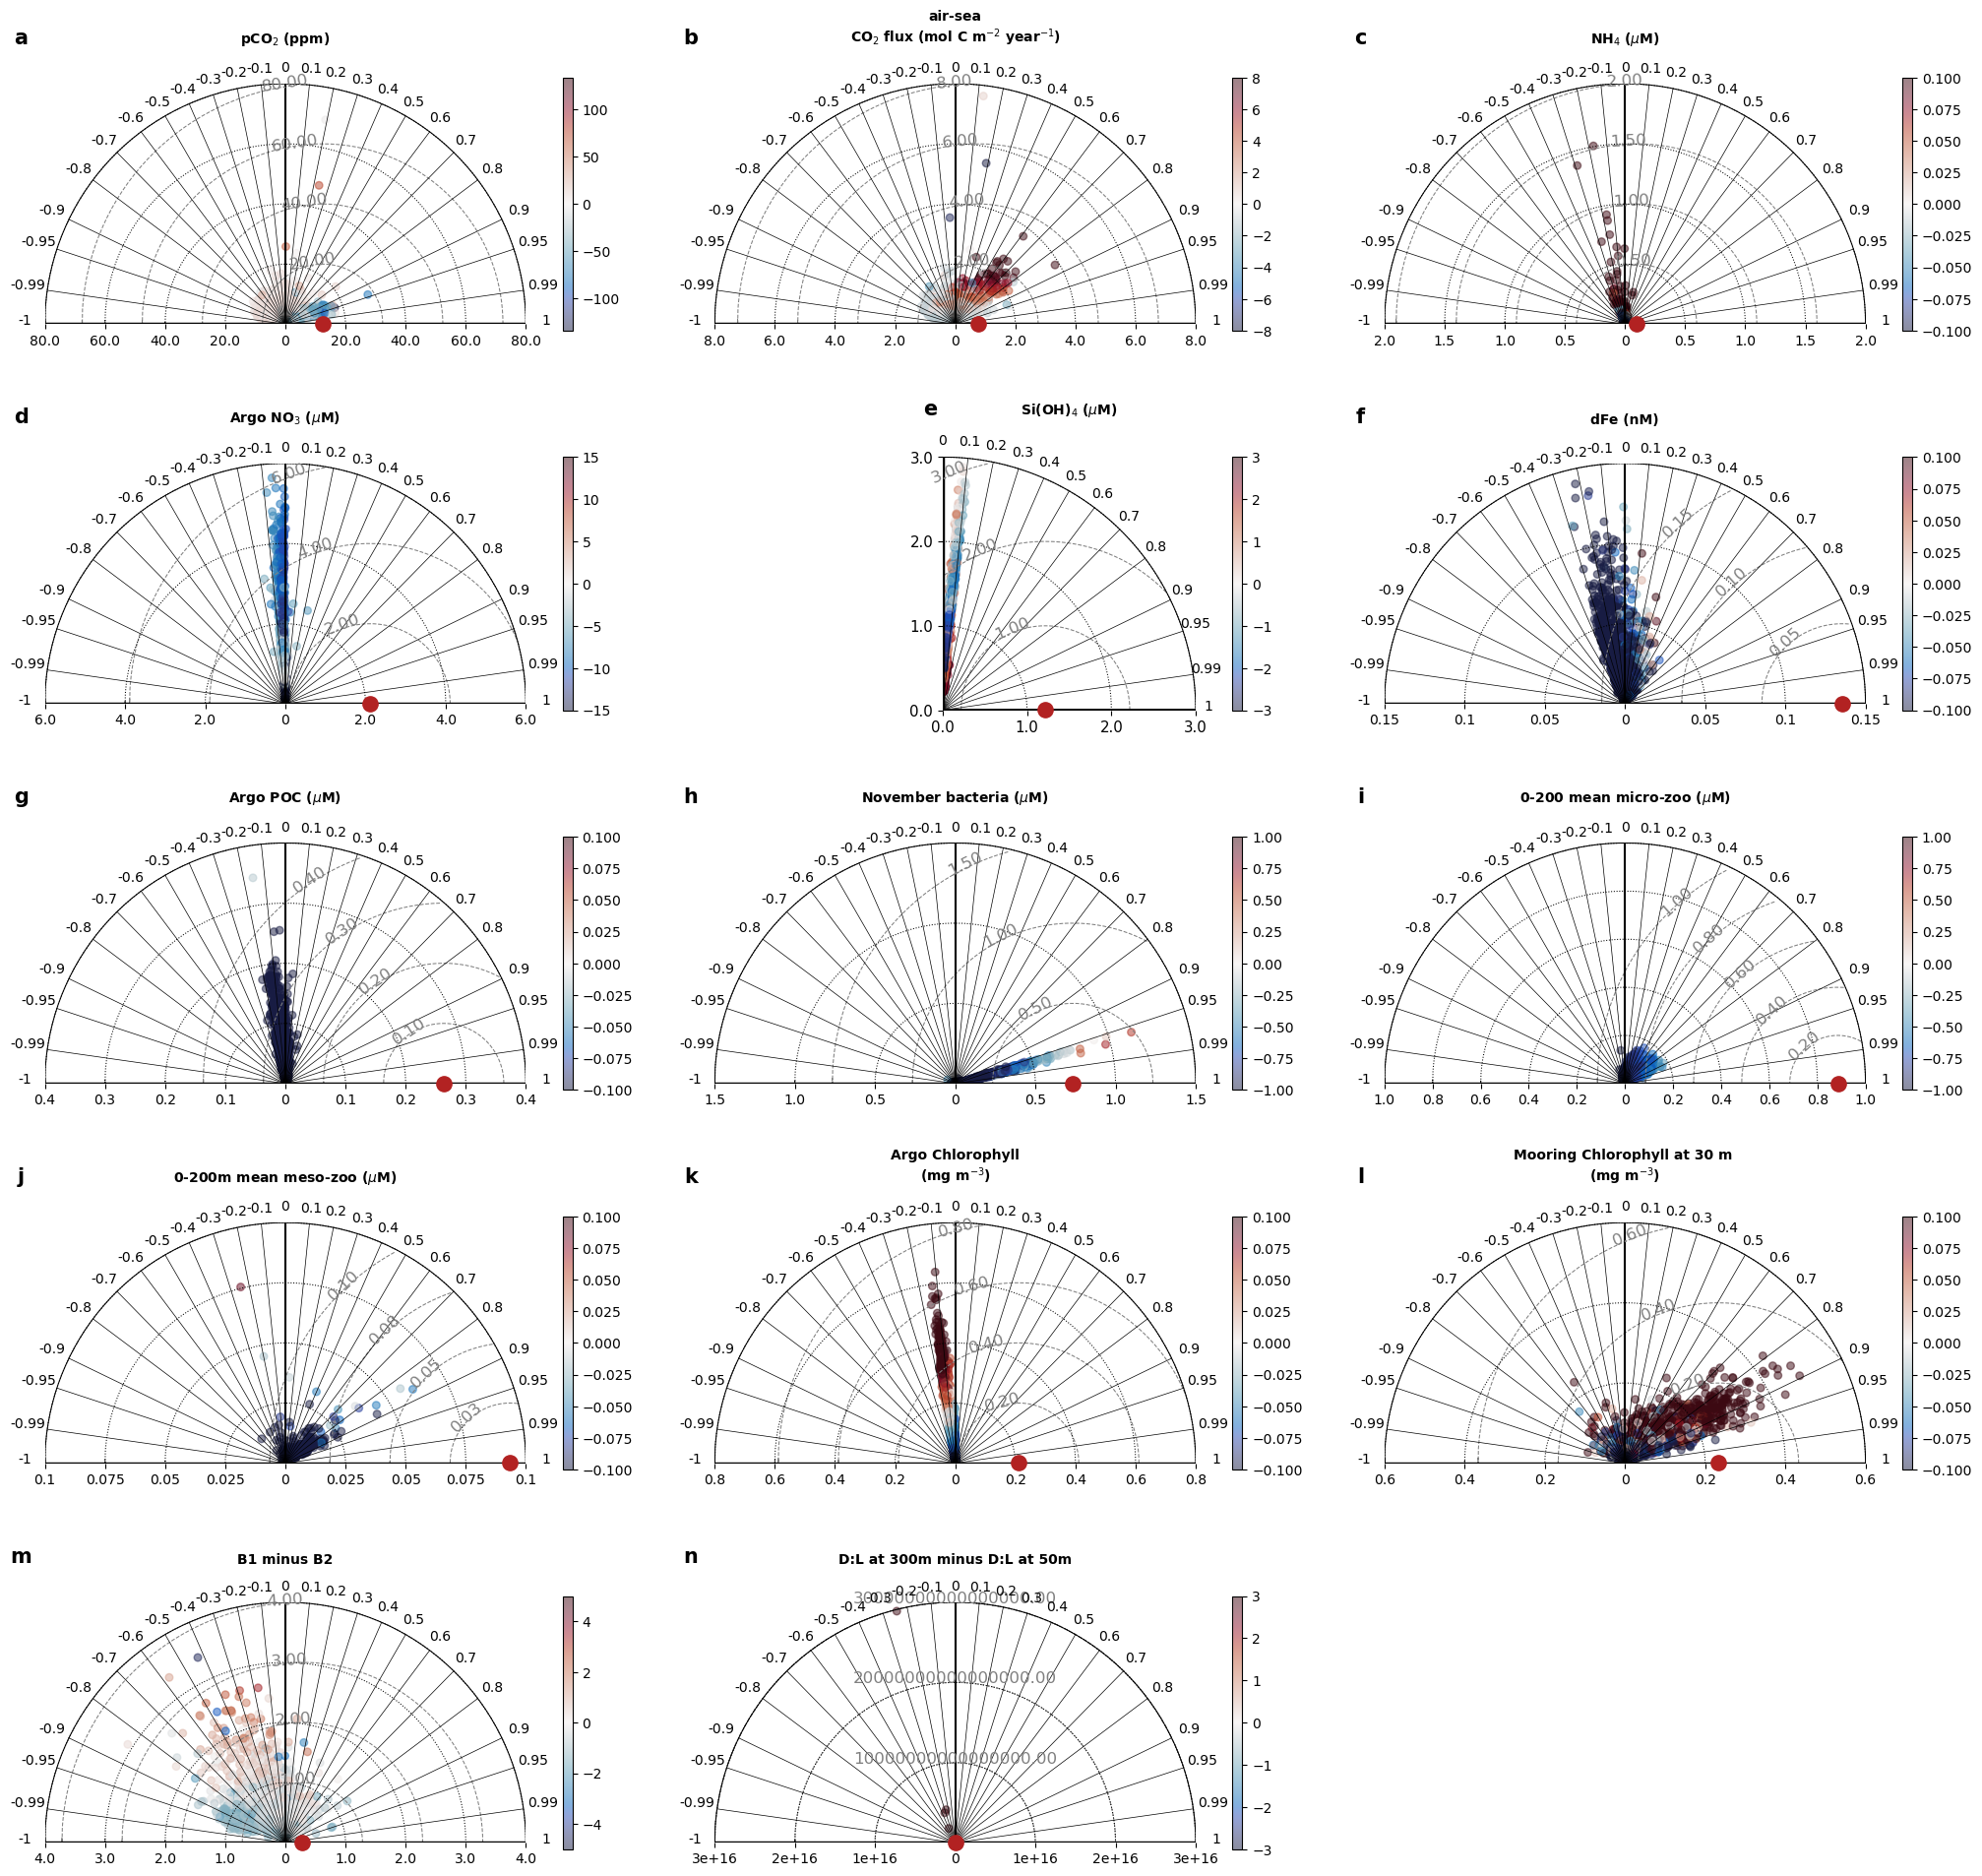

In [29]:

fslab = 15
fstic = 13


labs = ['pCO$_2$ (ppm)', \
        'air-sea\nCO$_2$ flux (mol C m$^{-2}$ year$^{-1}$)', \
        'NH$_4$ ($\mu$M)', \
        'Argo NO$_3$ ($\mu$M)', \
        'Si(OH)$_4$ ($\mu$M)', \
        'dFe (nM)', \
        'Argo POC ($\mu$M)', \
        'November bacteria ($\mu$M)', \
        '0-200 mean micro-zoo ($\mu$M)', \
        '0-200m mean meso-zoo ($\mu$M)', \
        'Argo Chlorophyll\n(mg m$^{-3}$)', \
        'Mooring Chlorophyll at 30 m \n(mg m$^{-3}$)', \
        'B1 minus B2', \
        'D:L at 300m minus D:L at 50m'
        ] 
letter = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n']

fig = plt.figure(figsize=(22,20))
gs = GridSpec(5, 3)

for vi,vv in enumerate(target_vars):
    ax = plt.subplot(gs[vi])

    vmin = 0 - np.abs(np.round(np.percentile(stats[vv+'_bias'],0.01),1)*1.2)
    vmax = 0 + np.abs(np.round(np.percentile(stats[vv+'_bias'],0.01),1)*1.2)
    vmin = 0 - np.abs(np.round(np.min(stats[vv+'_bias'])))
    vmax = 0 + np.abs(np.round(np.min(stats[vv+'_bias'])))
    statss = stats

    
    sm.taylor_diagram(np.array(statss[vv+'_sdev']), np.array(statss[vv+'_crmsd']), np.array(statss[vv+'_ccoef']), alpha=0.1, 
                      MarkerDisplayed='colorBar', cmapzdata=np.array(statss[vv+'_bias']), locationColorBar='EastOutside', titleColorBar=' ', 
                      cmap=lighten(cmo.balance,0.5), cmap_marker='o', markerSize=15, cmap_vmax=vmax, cmap_vmin=vmin, 
                      colRMS='grey', styleRMS='--', widthRMS=0.75, showlabelsRMS='on', titleRMS='off', rmsLabelFormat='0:.2f',
                      colSTD='k', styleSTD=':', widthSTD=0.75, showlabelsSTD='off', titleSTD='off', 
                      colCOR='k', styleCOR='-', widthCOR=0.5, showlabelsCOR='on', titleCOR='off', 
                      markerOBS='o', colOBS='firebrick')

    plt.text(0.5,1.15, labs[vi], transform=ax.transAxes, va='bottom', ha='center', fontweight='bold')
    plt.text(-0.05,1.15, letter[vi], fontweight='bold', fontsize=fslab, ha='center', va='bottom', transform=ax.transAxes)


plt.subplots_adjust(hspace=0.5, wspace=0.1, right=0.95, left=0.05, bottom=0.05, top=0.95)


os.chdir("/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/figures")
fig.savefig("assess_performance_TaylorDiagram_optimisation.png", dpi=300)
fig.savefig("assess_performance_TaylorDiagram_optimisation.pdf", dpi=300)
fig.savefig("assess_performance_TaylorDiagram_optimisation_transparent.png", dpi=300, transparent=True)


### Load the data and find out what the best experiments are

In [37]:
%%time

datadir = "/g/data/vn19/pjb581/SOTS-Optimization/WOMBATfull/data/output"

df_CCOEF = pd.read_excel(datadir + "/optimisation_CCOEF.xlsx")

df_NRMSE = pd.read_excel(datadir + "/optimisation_NRMSE.xlsx")

df_SDEV = pd.read_excel(datadir + "/optimisation_SDEV.xlsx")

df_BIAS = pd.read_excel(datadir + "/optimisation_BIAS.xlsx")


CPU times: user 5.71 s, sys: 2.19 s, total: 7.9 s
Wall time: 13.6 s


In [38]:
df_NRMSE.sort_values(by="fgco2_nrmse", ascending=True)


,pco2_nrmse,fgco2_nrmse,nh4_nrmse,no3_nrmse,sil_nrmse,dfe_nrmse,poc_nrmse,bac_nrmse,micro_nrmse,meso_nrmse,chl_bottle_nrmse,chl_mooring_nrmse,b1mb2_nrmse,D2L300mD2L50_nrmse,sum_nrmse
506,0.266238,0.317378,1.194641,1.431803,1.376869,1.577002,1.516968,0.347204,1.053075,0.930141,1.507426,1.348569,1.783022,1.210212,15.860548
124,0.222090,0.319396,1.226349,1.446896,1.355422,1.476571,1.462525,1.972542,1.040868,1.056822,1.491996,0.354032,1.826231,1.272000,16.523738
1814,0.322995,0.329484,1.537420,1.442758,1.377471,1.604916,1.545213,0.418950,1.040868,1.229482,1.527825,1.760604,1.679622,1.790556,17.608166
882,0.386660,0.357111,1.389856,1.438261,1.366189,1.425044,1.529197,1.966994,0.799049,1.254057,1.500186,1.308792,1.555545,1.372323,17.649264
1038,0.380712,0.360654,1.670996,1.430468,1.351688,1.526877,1.550850,1.076392,1.040868,0.664672,1.498251,1.286493,1.836894,1.081467,16.757282
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,1.964123,1.977590,1.381232,1.428507,1.391638,0.928823,1.385311,0.207206,1.714870,1.056822,1.457596,0.418264,1.792128,0.922949,18.027061
1071,1.976732,1.978316,1.616827,1.431587,1.390641,1.361564,1.479105,0.239116,1.363473,1.019893,1.477648,0.513149,1.492341,1.288225,18.628617
1525,1.975271,1.981016,1.331567,1.434167,1.384704,1.580246,1.484259,0.219640,1.775498,1.056822,1.488854,0.380802,1.636611,0.937220,18.666678
1545,1.977019,1.981316,1.641679,1.406274,1.357163,1.675112,1.489872,0.222036,1.890710,1.056822,1.491312,0.374009,1.807731,1.100645,19.471701


In [39]:
df_NRMSE.sort_values(by="b1mb2_nrmse", ascending=True)

,pco2_nrmse,fgco2_nrmse,nh4_nrmse,no3_nrmse,sil_nrmse,dfe_nrmse,poc_nrmse,bac_nrmse,micro_nrmse,meso_nrmse,chl_bottle_nrmse,chl_mooring_nrmse,b1mb2_nrmse,D2L300mD2L50_nrmse,sum_nrmse
1699,1.960930,1.943869,1.241315,1.433299,1.397387,1.517440,1.278841,0.182005,1.554594,1.111075,1.430860,1.702970,0.299069,0.419358,17.473011
1591,1.952230,1.955599,1.163470,1.436661,1.394626,1.558636,1.307837,1.984762,1.456130,1.137591,1.428486,1.707226,0.321212,0.590794,19.395260
1285,1.953533,1.955864,1.687965,1.432325,1.399324,1.471388,1.322605,0.726193,1.519149,1.134988,1.446673,1.820582,0.325202,0.642052,18.837843
1017,1.952701,1.955844,1.538196,1.434850,1.401959,1.338859,1.282224,0.249996,1.523530,1.114163,1.451731,1.782964,0.585915,0.589355,18.202286
254,1.800966,1.801989,1.578725,1.434872,1.372248,1.630342,1.339515,0.221049,1.723774,0.760646,1.411512,0.457232,0.596957,0.753594,16.883422
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
487,1.948322,1.938582,1.590297,1.444922,1.388729,1.429266,1.470240,1.840211,1.499901,0.932684,1.460177,1.577150,1.981042,1.062802,21.564324
1924,1.940075,1.896808,1.565161,1.433257,1.383647,1.641514,1.419682,0.247591,1.699271,1.138741,1.439107,1.179099,1.982538,1.746789,20.713279
64,1.849214,1.663758,1.545433,1.449707,1.389271,1.201819,1.368161,1.988138,1.618885,1.127884,1.386428,1.480730,1.982973,0.466178,20.518578
1649,1.815189,1.805976,1.375455,1.449377,1.351134,1.424195,1.588637,0.238484,1.040868,0.949251,1.534276,1.594687,1.984707,1.806962,19.959198


In [40]:
df_cost = (1.0 - df_CCOEF['fgco2_ccoef'])

df_cost.sort_values(ascending=True)[0:20]

506     0.050365
124     0.051007
1814    0.054280
882     0.063764
1038    0.065036
239     0.077096
582     0.082140
706     0.089705
1453    0.123376
807     0.125664
932     0.126305
664     0.132388
2032    0.134960
959     0.140123
1928    0.147338
2026    0.152208
1557    0.152399
1239    0.155715
400     0.167705
1258    0.170975
Name: fgco2_ccoef, dtype: float64